# Semantic Document Search with ChromaDB & Google Gemini

Some well known Vector Databases:
1. MongoDB
2. [ChromaDB](https://www.trychroma.com/)
3. Pinecone
4. Wievate

## ChromaDB
Chroma is an AI-native open-source vector database. It is primarily optimized for single machine performance. For massive, planet-scale datasets requiring distributed clusters, developers often look toward enterprise solutions like Pinecone, Weaviate. You can setup ChromaDBlocally or for production, Chroma offers Chroma Cloud - a fast, scalable, and serverless database-as-a-service.

For this exercise, we will spin a ChromaDB locally.

In [3]:
"""
q is the magic quiet funciton to avoid all the progress message.

-U: Pip checks the internet for the newest version and upgrades. Without -U: If the package is already on your computer, pip will see it and say "Requirement already satisfied" and stop. It won't check if a newer version exists.
"""
!pip install -q -U chromadb google-generativeai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/4

To bridge ChromaDB with Gemini we will use ChromaDB's built in utility.

In [10]:
import os
import chromadb
import google.generativeai as genai
from chromadb.utils import embedding_functions
from google.colab import userdata


# 1. Pull the secret safely
try:
    API_KEY = userdata.get('api_key') # Make sure this matches the Name in the 🔑 tab
except userdata.SecretNotFoundError:
    print("Error: The secret 'GEMINI_API_KEY' was not found in the Secrets tab.")

# 2. Setup Embedding Function
# Using .strip() is a good habit to remove accidental newlines
gemini_ef = embedding_functions.GoogleGenerativeAiEmbeddingFunction(
    api_key=API_KEY.strip(),
    model_name="models/text-embedding-004"
)

In [5]:
#PersistentClient creates a physical folder on your hard drive (at the ./my_local_db path).
client = chromadb.PersistentClient(path="./chroma_db")

In [6]:
# everytime you save a document in the folder it sends it to gemini for vectorizing
collection = client.get_or_create_collection(
    name="my_documents",
    embedding_function=gemini_ef
)

In [7]:
# this dropbox hosts some articles that we can use for this exercise
!wget -q https://www.dropbox.com/s/vs6ocyvpzzncvwh/new_articles.zip

By now you'll see 2 folders created in your local directory. 'chroma_db' and 'sample_data' (created by chromaDB)

In [8]:
# unzip the files
!unzip -q new_articles.zip -d /content/my_documents

In [11]:
#This script will loop through every .txt file in the folder, read the text, and store it in ChromaDB
import glob

# Path where the files are located
directory_path = "/content/my_documents"

# Lists to hold our data
documents = []
metadatas = []
ids = []

# Loop through all .txt files in the directory
for i, file_path in enumerate(glob.glob(os.path.join(directory_path, "*.txt"))):
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

        # We only add the file if it's not empty
        if content.strip():
            documents.append(content)
            # Metadata helps you filter results later (e.g., search only in a specific file)
            metadatas.append({"source": os.path.basename(file_path)})
            ids.append(f"doc_{i}")

# Add everything to the collection
if documents:
    collection.add(
        documents=documents,
        metadatas=metadatas,
        ids=ids
    )
    print(f"Successfully added {len(documents)} documents to ChromaDB.")
else:
    print("No text files found or files were empty.")

Successfully added 21 documents to ChromaDB.


What happens inside `collection.add()`?

**Automatic Embedding**: Because we attached gemini_ef to the collection in Step 2, ChromaDB automatically sends your documents (the raw text) to the Gemini API.

**Vector Generation**: Gemini’s servers process that text and return a vector (a long list of numbers, like [0.12, -0.04, 0.89, ...]) for each document.

**Storage**: ChromaDB then saves three distinct things for every entry:

1. The Vector: The mathematical representation used for "finding" the data.

2. The Document: The original raw text (so it can show you the answer later).

3. The Metadata: The extra info you provided, like the filename.

In [12]:
#Search the DB using natural language
results = collection.query(
    query_texts=["What is the main topic of these articles?"],
    n_results=2 # Number of results to return
)

for doc in results['documents'][0]:
    print(f"Result: {doc[:200]}...") # Print first 200 chars of matches

Result: Vint Cerf on the ‘exhilarating mix’ of thrill and hazard at the frontiers of tech 'That's always an exciting place to be — a place where nobody's ever been before.'

Vint Cerf has been a near-constant...
Result: ChatGPT: Everything you need to know about the AI-powered chatbot

ChatGPT, OpenAI’s text-generating AI chatbot, has taken the world by storm. It’s able to write essays, code and more given short text...


The ids must be unique. If you run this script twice, you might get an error saying the ID already exists. You can use `collection.upsert()` instead of `collection.add()` to overwrite existing entries instead of crashing.

##Chunking

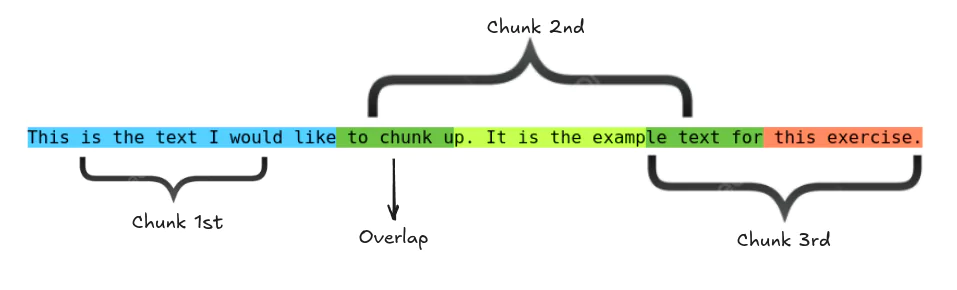

If your text files are very long (like entire books), you should break them into smaller "chunks" (e.g., 500 words each). Large chunks make search results less precise.

Implementing chunking with LangChain is much easier because it provides a dedicated tool called the `RecursiveCharacterTextSplitter`

In [13]:
#Install the LangChain Google integration and the community package
!pip install -q -U langchain-google-genai langchain-community

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.4/719.4 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.9/234.9 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.43.0, but you have google-auth 2.47.0 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompa

In [14]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import Chroma
from google.colab import userdata
import os

In [15]:

# 1. Setup the Gemini Embedding Model for LangChain
API_KEY = userdata.get('api_key').strip()
embeddings = GoogleGenerativeAIEmbeddings(
    model="models/text-embedding-004",
    google_api_key=API_KEY
)

In [16]:
# 2. Configure the Splitter
# chunk_size: Max characters per chunk
# chunk_overlap: Number of characters to "carry over" from the previous chunk
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", " ", ""] # Order of priority for splitting
)

In [17]:
# 3. Load and Split your files
all_langchain_docs = []
directory_path = "/content/my_documents"

for file_name in os.listdir(directory_path):
    if file_name.endswith(".txt"):
        with open(os.path.join(directory_path, file_name), 'r') as f:
            text = f.read()
            # split_text creates a list of strings
            # create_documents creates LangChain 'Document' objects with metadata
            chunks = text_splitter.create_documents(
                texts=[text],
                metadatas=[{"source": file_name}]
            )
            all_langchain_docs.extend(chunks)

In [18]:
# 4. Store in ChromaDB (LangChain Wrapper)
vector_db = Chroma.from_documents(
    documents=all_langchain_docs,
    embedding=embeddings,
    persist_directory="./chroma_langchain_db"
)

print(f"Created {len(all_langchain_docs)} smart chunks.")

Created 233 smart chunks.


Learn more about chunking [here](https://youtu.be/_GEitI9PU28)

### 1. Simple Similarity Search

In [22]:
query = "What information is available about AI replacing tv writers?"

# k=3 means 'give me the top 3 most similar chunks'
docs = vector_db.similarity_search(query, k=3)

for i, doc in enumerate(docs):
    print(f"\n--- Result {i+1} ---")
    print(f"Source: {doc.metadata.get('source')}")
    print(f"Content: {doc.page_content[:200]}...") # Print first 200 chars


--- Result 1 ---
Source: 05-03-ai-replace-tv-writers-strike.txt
Content: In the must-watch final season of “Succession,” Kendall Roy enters a conference room with his siblings. As the scene opens, he takes a seat and declares: “Who will be the successor? Me.”

Of course, t...

--- Result 2 ---
Source: 05-03-ai-replace-tv-writers-strike.txt
Content: Conover emphasized that some parts of a writer’s job are less obvious than literal scriptwriting but equally difficult to replicate with AI.

“It’s going and meeting with the set decoration department...

--- Result 3 ---
Source: 05-03-ai-replace-tv-writers-strike.txt
Content: But even if there may be some promise for how humans can leverage this technology, he worries that studios see it merely as a way to demand more from writers over a shorter period of time.

“It says t...


### 2. Search with Relevance Scores

If you want to know how sure the database is about a match, use this method.

Note: For ChromaDB, the "score" is usually a distance (Euclidean). Lower is better (0.0 is a perfect match).

In [20]:
# Returns a list of (Document, Score) tuples
results_with_score = vector_db.similarity_search_with_score(query, k=2)

for doc, score in results_with_score:
    print(f"\nScore (Lower is better): {score:.4f}")
    print(f"Content snippet: {doc.page_content[:150]}...")


Score (Lower is better): 0.9071
Content snippet: “We’ve spoken to quite a few organizations, with many conversations being too premature to announce, and think that our funding announcement and incre...

Score (Lower is better): 1.0102
Content snippet: To boost visibility, Spawning is partnering with Hugging Face, one of the larger platforms for hosting and running AI models, to add a new info box on...


### 3. The "Retriever" Method (Best for Chatbots)

In LangChain, you often don't want to handle the search results manually. Instead, you convert your database into a Retriever. This object can be passed into a "RetrievalQA" chain or a Chat agent.

In [24]:
# Convert the vector store into a retriever
retriever = vector_db.as_retriever(search_kwargs={"k": 3})

# You can now invoke it directly
relevant_chunks = retriever.invoke("reviews about cma generative ai")
relevant_chunks

[Document(metadata={'source': '05-04-cma-generative-ai-review.txt'}, page_content='The CMA says its initial review of foundational AI models is in line with instructions in the white paper, where the government talked about existing regulators conducting “detailed risk analysis” in order to be in a position to carry out potential enforcements, i.e. on dangerous, unfair and unaccountable applications of AI, using their existing powers.\n\nThe regulator also points to its core mission — to support open, competitive markets — as another reason for taking a look at generative AI now.\n\nNotably, the competition watchdog is set to get additional powers to regulate Big Tech in the coming years, under plans taken off the back-burner by prime minister Rishi Sunak’s government last month, when ministers said it would move forward with a long-trailed (but much delayed) ex ante reform aimed at digital giants’ market power.'),
 Document(metadata={'source': '05-04-cma-generative-ai-review.txt'}, pa